<a href="https://colab.research.google.com/github/arpittyagi2/python_learning/blob/main/Day4_Notebook_01_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# ==============================================================================
# CELL 0: ENVIRONMENT SETUP & SYNTHETIC DATASET GENERATION
# Run this cell first to generate `day4_retail_bi.csv` directly in Colab.
# ==============================================================================
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set global rendering quality
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Seed for absolute reproducibility
np.random.seed(42)
n_samples = 1500

# 1. Temporal feature
date_range = pd.date_range(start="2024-01-01", end="2024-12-31", periods=n_samples)

# 2. Categorical features
regions = np.random.choice(["North America", "Europe", "Asia-Pacific", "Latin America"], size=n_samples, p=[0.40, 0.30, 0.20, 0.10])
customer_tier = np.random.choice(["Standard", "Silver", "Gold", "Platinum"], size=n_samples, p=[0.50, 0.25, 0.15, 0.10])
product_category = np.random.choice(["Hardware", "SaaS Subscriptions", "Consulting", "Support Add-ons"], size=n_samples, p=[0.35, 0.30, 0.20, 0.15])

# 3. Numerical features with realistic correlations
units = np.random.poisson(lam=4, size=n_samples).clip(1, 20)
base_prices = {"Hardware": 450.0, "SaaS Subscriptions": 120.0, "Consulting": 250.0, "Support Add-ons": 75.0}
unit_price = np.array([base_prices[cat] for cat in product_category]) * np.random.uniform(0.85, 1.15, size=n_samples)

discount_pct = np.random.beta(a=2, b=8, size=n_samples) * 0.40 # Discounts between 0% and 40%
gross_revenue = units * unit_price
net_revenue = gross_revenue * (1 - discount_pct)
cost_price = gross_revenue * np.random.uniform(0.40, 0.65, size=n_samples)
profit_margin = ((net_revenue - cost_price) / net_revenue) * 100
csat_score = (np.random.normal(loc=4.2, scale=0.6, size=n_samples) - (discount_pct * 1.5)).clip(1.0, 5.0)

# Build DataFrame
df = pd.DataFrame({
    "Date": date_range,
    "Region": regions,
    "Customer_Tier": customer_tier,
    "Category": product_category,
    "Units_Sold": units,
    "Unit_Price": np.round(unit_price, 2),
    "Gross_Revenue": np.round(gross_revenue, 2),
    "Discount_Pct": np.round(discount_pct, 4),
    "Net_Revenue": np.round(net_revenue, 2),
    "Profit_Margin_Pct": np.round(profit_margin, 2),
    "CSAT_Score": np.round(csat_score, 2)
})

# Add temporal aggregations
df["Month"] = df["Date"].dt.to_period("M").dt.to_timestamp()
df["Month_Name"] = df["Date"].dt.strftime("%b")

df.to_csv("day4_retail_bi.csv", index=False)
print("✅ Synthetic dataset 'day4_retail_bi.csv' generated successfully!")
print(f"Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head(3))

✅ Synthetic dataset 'day4_retail_bi.csv' generated successfully!
Dimensions: 1500 rows × 13 columns


,Date,Region,Customer_Tier,Category,Units_Sold,Unit_Price,Gross_Revenue,Discount_Pct,Net_Revenue,Profit_Margin_Pct,CSAT_Score,Month,Month_Name
0,2024-01-01 00:00:00.000000000,North America,Silver,Consulting,3,224.70,674.09,0.0812,619.32,48.43,4.20,2024-01-01,Jan
1,2024-01-01 05:50:38.025350233,Latin America,Standard,Consulting,3,241.60,724.81,0.0821,665.29,46.58,4.48,2024-01-01,Jan
2,2024-01-01 11:41:16.050700466,Asia-Pacific,Standard,Hardware,4,407.56,1630.23,0.0869,1488.49,39.14,3.95,2024-01-01,Jan


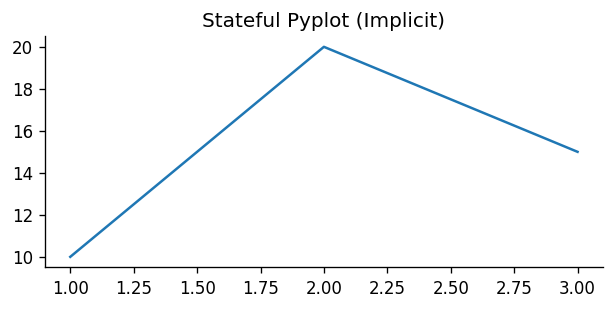

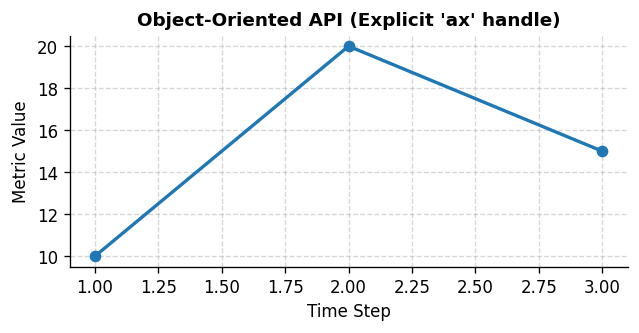

In [19]:
# ==============================================================================
# SECTION 1: MATPLOTLIB ARCHITECTURE (Pyplot vs. Object-Oriented API)
# ==============================================================================
"""
MATPLOTLIB ARCHITECTURAL HIERARCHY:

   ┌────────────────────────────────────────────────────────┐
   │ Figure (The overall canvas window/page)                 │
   │  ┌──────────────────────────────────────────────────┐  │
   │  │ Axes (The actual plot canvas: x-axis, y-axis)    │  │
   │  │   • Title, Labels, Legend, Spines, Ticks         │  │
   │  │   • Artists: Line2D, Bar, Scatter collections    │  │
   │  └──────────────────────────────────────────────────┘  │
   └────────────────────────────────────────────────────────┘

WHY THE OBJECT-ORIENTED (OO) API SCALES BETTER THAN PYPLOT:
1. Pyplot (plt.plot) maintains state implicitly in a global hidden engine (prone to overwriting).
2. The OO API (`fig, ax = plt.subplots()`) treats Figures and Axes as explicit Python objects.
3. OO is modular, thread-safe, and mandatory for multi-panel dashboards.
"""

# Stateful Pyplot Style (AVOID for complex layouts)
plt.figure(figsize=(6, 2.5))
plt.plot([1, 2, 3], [10, 20, 15])
plt.title("Stateful Pyplot (Implicit)")
plt.show()

# Explicit Object-Oriented (OO) API (INDUSTRY BEST PRACTICE)
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.plot([1, 2, 3], [10, 20, 15], color="#1f77b4", linewidth=2, marker="o")
ax.set_title("Object-Oriented API (Explicit 'ax' handle)", fontsize=11, fontweight="bold")
ax.set_xlabel("Time Step")
ax.set_ylabel("Metric Value")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

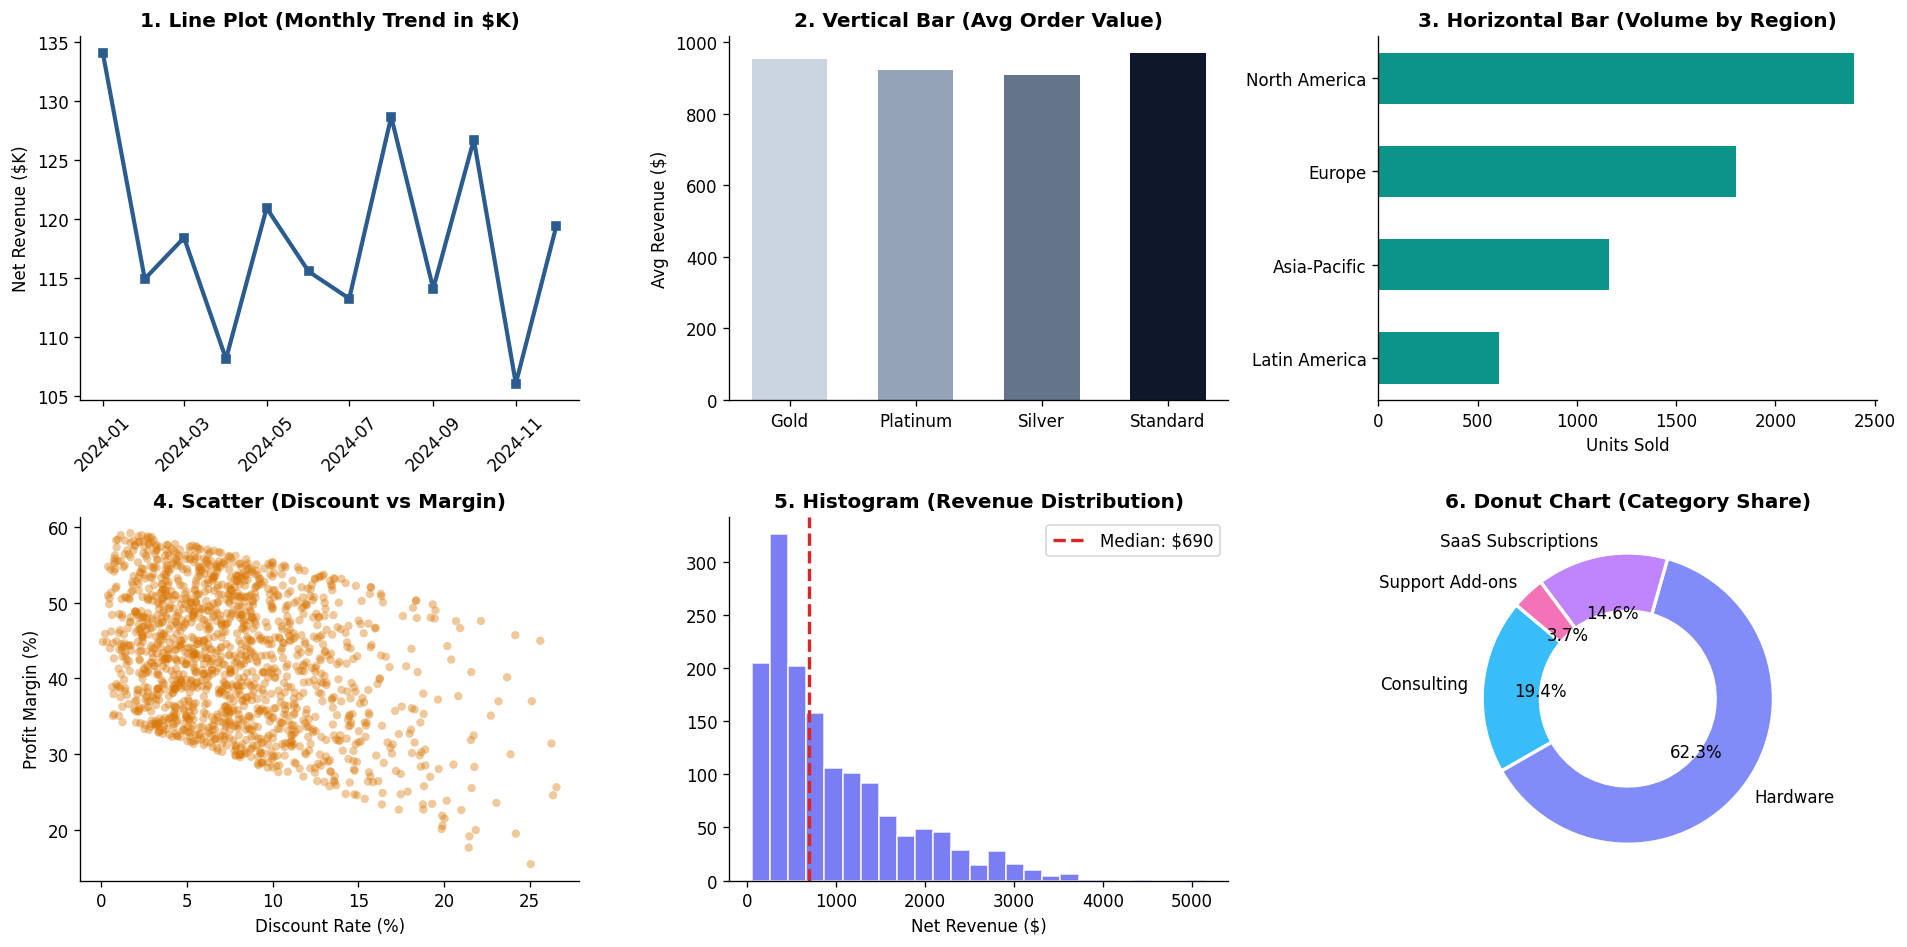

In [20]:
# ==============================================================================
# SECTION 2: CORE MATPLOTLIB PLOT TYPES & ADVANCED CUSTOMISATION
# ==============================================================================
# Visualising 6 core visual types using clean OO styling:
# Line, Bar, Horizontal Bar, Scatter, Histogram, Donut/Pie

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# 1. Line Plot (Trend)
monthly_trend = df.groupby("Month")["Net_Revenue"].sum()
axes[0, 0].plot(monthly_trend.index, monthly_trend.values / 1000, color="#2b5c8f", lw=2.5, marker="s", ms=5)
axes[0, 0].set_title("1. Line Plot (Monthly Trend in $K)", fontweight="bold")
axes[0, 0].set_ylabel("Net Revenue ($K)")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Vertical Bar Chart (Discrete Comparison)
tier_rev = df.groupby("Customer_Tier")["Net_Revenue"].mean()
axes[0, 1].bar(tier_rev.index, tier_rev.values, color=["#cbd5e1", "#94a3b8", "#64748b", "#0f172a"], width=0.6)
axes[0, 1].set_title("2. Vertical Bar (Avg Order Value)", fontweight="bold")
axes[0, 1].set_ylabel("Avg Revenue ($)")

# 3. Horizontal Bar Chart (Ranking/Categorical Long Labels)
reg_units = df.groupby("Region")["Units_Sold"].sum().sort_values()
axes[0, 2].barh(reg_units.index, reg_units.values, color="#0d9488", height=0.55)
axes[0, 2].set_title("3. Horizontal Bar (Volume by Region)", fontweight="bold")
axes[0, 2].set_xlabel("Units Sold")

# 4. Scatter Plot (Relationship)
axes[1, 0].scatter(df["Discount_Pct"] * 100, df["Profit_Margin_Pct"], color="#d97706", alpha=0.4, edgecolors="none", s=25)
axes[1, 0].set_title("4. Scatter (Discount vs Margin)", fontweight="bold")
axes[1, 0].set_xlabel("Discount Rate (%)")
axes[1, 0].set_ylabel("Profit Margin (%)")

# 5. Histogram with Annotation (Distribution)
n, bins, patches = axes[1, 1].hist(df["Net_Revenue"], bins=25, color="#6366f1", edgecolor="white", alpha=0.85)
med_val = df["Net_Revenue"].median()
axes[1, 1].axvline(med_val, color="#dc2626", linestyle="--", lw=2, label=f"Median: ${med_val:,.0f}")
axes[1, 1].set_title("5. Histogram (Revenue Distribution)", fontweight="bold")
axes[1, 1].set_xlabel("Net Revenue ($)")
axes[1, 1].legend()

# 6. Donut Chart (Composition)
cat_shares = df.groupby("Category")["Net_Revenue"].sum()
wedges, texts, autotexts = axes[1, 2].pie(
    cat_shares, labels=cat_shares.index, autopct="%1.1f%%",
    startangle=140, colors=["#38bdf8", "#818cf8", "#c084fc", "#f472b6"],
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)
axes[1, 2].set_title("6. Donut Chart (Category Share)", fontweight="bold")

plt.tight_layout()
plt.show()

/tmp/ipykernel_2726/461953639.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Region", y="Net_Revenue", ax=ax1, palette="Blues", fliersize=2)


✅ Figure exported to 'publication_quality_chart.png' at 300 DPI!


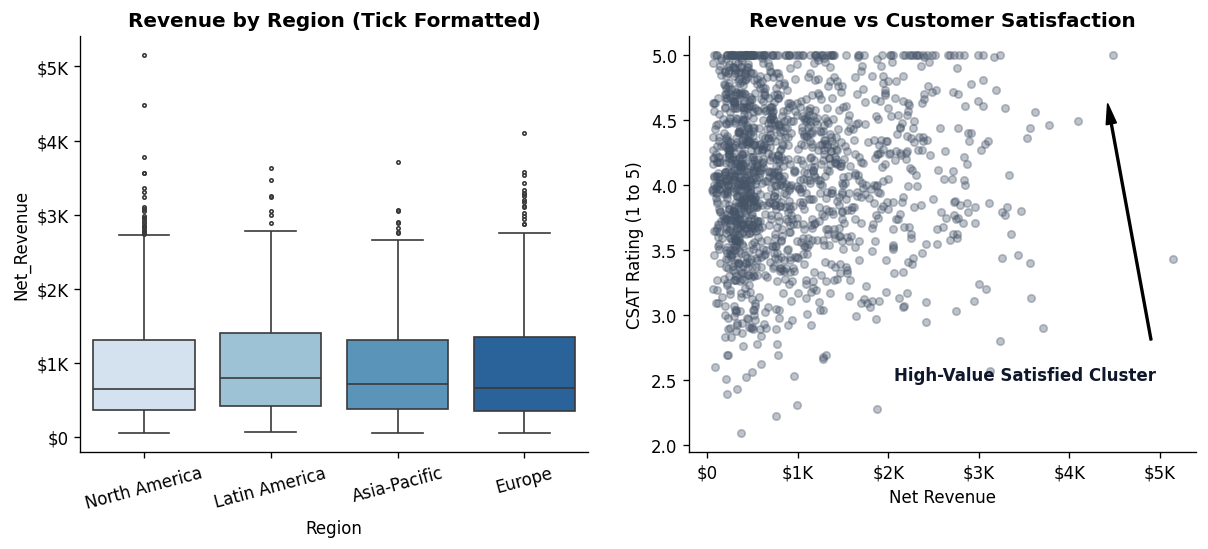

In [21]:
# ==============================================================================
# SECTION 3: SUBPLOTS, TICK FORMATTING & PUBLICATION-QUALITY EXPORT
# ==============================================================================
# Demonstrating formatting tickers with currency and exporting at 300 DPI

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

# Currency Formatter Function
def currency_fmt(x, pos):
    return f"${x*1e-3:.0f}K" if x >= 1000 else f"${x:.0f}"

# Left: Boxplot with Custom Formatter
sns.boxplot(data=df, x="Region", y="Net_Revenue", ax=ax1, palette="Blues", fliersize=2)
ax1.set_title("Revenue by Region (Tick Formatted)", fontweight="bold")
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(currency_fmt))
ax1.tick_params(axis='x', rotation=15)

# Right: Annotated Scatter
ax2.scatter(df["Net_Revenue"], df["CSAT_Score"], color="#475569", alpha=0.35, s=20)
ax2.set_title("Revenue vs Customer Satisfaction", fontweight="bold")
ax2.set_xlabel("Net Revenue")
ax2.set_ylabel("CSAT Rating (1 to 5)")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(currency_fmt))

# Annotation pointer
ax2.annotate(
    "High-Value Satisfied Cluster",
    xy=(df["Net_Revenue"].max() * 0.85, 4.8),
    xytext=(df["Net_Revenue"].max() * 0.40, 2.5),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight="bold", color="#0f172a"
)

# Export at 300 DPI for Academic / Presentation Publication
fig.savefig("publication_quality_chart.png", dpi=300, bbox_inches="tight")
print("✅ Figure exported to 'publication_quality_chart.png' at 300 DPI!")
plt.show()

In [22]:
# ==============================================================================
# SECTION 4: CHART SELECTION DECISION MATRIX
# ==============================================================================
"""
DECISION FRAMEWORK: MATCHING BUSINESS QUESTION TO VISUAL TYPE

┌───────────────────┬───────────────────────────────────┬───────────────────────────────┐
│ Primary Goal      │ Visual Type                       │ Recommended Python Syntax     │
├───────────────────┼───────────────────────────────────┼───────────────────────────────┤
│ 1. TREND          │ Line Chart, Area Chart            │ ax.plot(), sns.lineplot()     │
│ 2. DISTRIBUTION   │ Histogram, KDE, Box, Violin       │ sns.histplot(), sns.boxplot() │
│ 3. COMPARISON     │ Bar Chart, Horizontal Bar         │ ax.bar(), sns.barplot()       │
│ 4. RELATIONSHIP   │ Scatter Plot, Regplot, Heatmap    │ sns.scatterplot(), regplot()  │
│ 5. COMPOSITION    │ Stacked Bar, Donut, Treemap       │ ax.pie(wedgeprops=...), bar() │
└───────────────────┴───────────────────────────────────┴───────────────────────────────┘
"""

'\nDECISION FRAMEWORK: MATCHING BUSINESS QUESTION TO VISUAL TYPE\n\n┌───────────────────┬───────────────────────────────────┬───────────────────────────────┐\n│ Primary Goal      │ Visual Type                       │ Recommended Python Syntax     │\n├───────────────────┼───────────────────────────────────┼───────────────────────────────┤\n│ 1. TREND          │ Line Chart, Area Chart            │ ax.plot(), sns.lineplot()     │\n│ 2. DISTRIBUTION   │ Histogram, KDE, Box, Violin       │ sns.histplot(), sns.boxplot() │\n│ 3. COMPARISON     │ Bar Chart, Horizontal Bar         │ ax.bar(), sns.barplot()       │\n│ 4. RELATIONSHIP   │ Scatter Plot, Regplot, Heatmap    │ sns.scatterplot(), regplot()  │\n│ 5. COMPOSITION    │ Stacked Bar, Donut, Treemap       │ ax.pie(wedgeprops=...), bar() │\n└───────────────────┴───────────────────────────────────┴───────────────────────────────┘\n'

/tmp/ipykernel_2726/767583228.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


TypeError: cannot unpack non-iterable numpy.float64 object

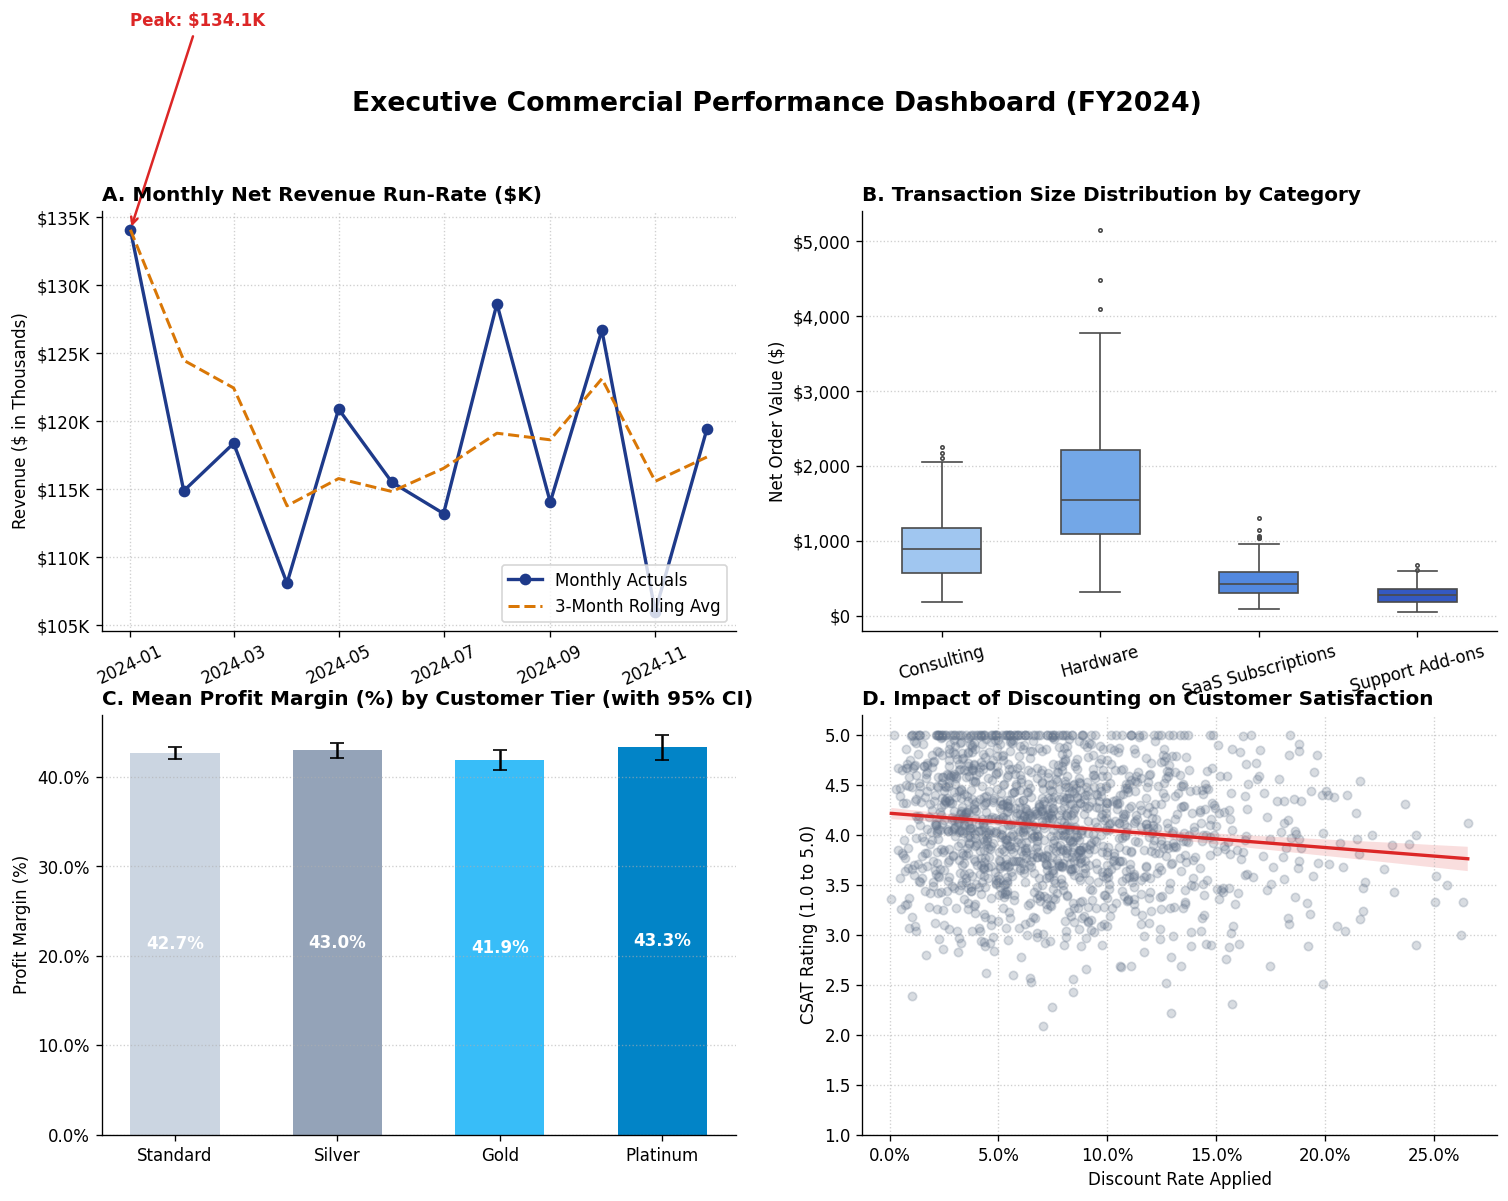

In [23]:
# ==============================================================================
# SECTION 5: LIVE DEMO — 4-PANEL PUBLICATION-READY DASHBOARD
# ==============================================================================
# Building a structured 2x2 presentation-grade visual dashboard for executive review.

# 1. Canvas Setup
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Executive Commercial Performance Dashboard (FY2024)", fontsize=16, fontweight="bold", y=0.98)

# Palette
PRIMARY_COLOR = "#1e3a8a"
ACCENT_COLOR = "#dc2626"
BG_GRID = "#f1f5f9"

# ------------------------------------------------------------------------------
# PANEL 1 (Top-Left): TREND — Monthly Revenue Run-Rate
# ------------------------------------------------------------------------------
monthly_summary = df.groupby("Month")["Net_Revenue"].sum().reset_index()
monthly_summary["Rolling_3M"] = monthly_summary["Net_Revenue"].rolling(3, min_periods=1).mean()

axes[0, 0].plot(monthly_summary["Month"], monthly_summary["Net_Revenue"] / 1e3, marker="o", color=PRIMARY_COLOR, lw=2, label="Monthly Actuals")
axes[0, 0].plot(monthly_summary["Month"], monthly_summary["Rolling_3M"] / 1e3, linestyle="--", color="#d97706", lw=1.8, label="3-Month Rolling Avg")
axes[0, 0].set_title("A. Monthly Net Revenue Run-Rate ($K)", fontweight="bold", loc="left")
axes[0, 0].set_ylabel("Revenue ($ in Thousands)")
axes[0, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.0fK"))
axes[0, 0].tick_params(axis='x', rotation=25)
axes[0, 0].grid(True, linestyle=":", alpha=0.6)
axes[0, 0].legend(frameon=True, facecolor="white", loc="lower right")

# Peak annotation
max_rev = monthly_summary["Net_Revenue"].max()
max_date = monthly_summary.loc[monthly_summary["Net_Revenue"].idxmax(), "Month"]
axes[0, 0].annotate(
    f"Peak: ${max_rev/1e3:.1f}K",
    xy=(max_date, max_rev / 1e3),
    xytext=(max_date, (max_rev / 1e3) + 15),
    arrowprops=dict(arrowstyle="->", color=ACCENT_COLOR, lw=1.5),
    fontweight="bold", color=ACCENT_COLOR
)

# ------------------------------------------------------------------------------
# PANEL 2 (Top-Right): DISTRIBUTION — Order Value Spread by Category
# ------------------------------------------------------------------------------
sns.boxplot(
    data=df, x="Category", y="Net_Revenue",
    palette=["#93c5fd", "#60a5fa", "#3b82f6", "#1d4ed8"],
    ax=axes[0, 1], width=0.5, fliersize=2
)
axes[0, 1].set_title("B. Transaction Size Distribution by Category", fontweight="bold", loc="left")
axes[0, 1].set_ylabel("Net Order Value ($)")
axes[0, 1].set_xlabel("")
axes[0, 1].yaxis.set_major_formatter(ticker.StrMethodFormatter("${x:,.0f}"))
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].grid(True, axis='y', linestyle=":", alpha=0.6)

# ------------------------------------------------------------------------------
# PANEL 3 (Bottom-Left): COMPARISON — Average Margin by Customer Tier
# ------------------------------------------------------------------------------
tier_margin = df.groupby("Customer_Tier")["Profit_Margin_Pct"].agg(["mean", "sem"]).reindex(["Standard", "Silver", "Gold", "Platinum"])
bars = axes[1, 0].bar(
    tier_margin.index, tier_margin["mean"],
    yerr=tier_margin["sem"] * 1.96, # 95% Error Bar
    color=["#cbd5e1", "#94a3b8", "#38bdf8", "#0284c7"],
    capsize=4, width=0.55, edgecolor="none"
)
axes[1, 0].set_title("C. Mean Profit Margin (%) by Customer Tier (with 95% CI)", fontweight="bold", loc="left")
axes[1, 0].set_ylabel("Profit Margin (%)")
axes[1, 0].yaxis.set_major_formatter(ticker.PercentFormatter())
axes[1, 0].grid(True, axis='y', linestyle=":", alpha=0.6)

# Add direct data labels inside/above bars
for bar in bars:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height/2, f"{height:.1f}%", ha='center', va='center', color="white" if height > 35 else "black", fontweight="bold")

# ------------------------------------------------------------------------------
# PANEL 4 (Bottom-Right): RELATIONSHIP — Discount vs CSAT Correlation
# ------------------------------------------------------------------------------
sns.regplot(
    data=df, x="Discount_Pct", y="CSAT_Score",
    scatter_kws={"color": "#64748b", "alpha": 0.25, "s": 25},
    line_kws={"color": ACCENT_COLOR, "linewidth": 2},
    ax=axes[1, 1]
)
axes[1, 1].set_title("D. Impact of Discounting on Customer Satisfaction", fontweight="bold", loc="left")
axes[1, 1].set_xlabel("Discount Rate Applied")
axes[1, 1].set_ylabel("CSAT Rating (1.0 to 5.0)")
axes[1, 1].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
axes[1, 1].set_ylim(1.0, 5.2)
axes[1, 1].grid(True, linestyle=":", alpha=0.6)

# Statistical coefficient annotation
r_val, _ = np.corrcoef(df["Discount_Pct"], df["CSAT_Score"])[0, 1]
axes[1, 1].text(
    0.05, 1.5, f"Pearson r = {r_val:.2f} (Negative Drag)",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="#cbd5e1", alpha=0.9),
    fontweight="bold", color=ACCENT_COLOR
)

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

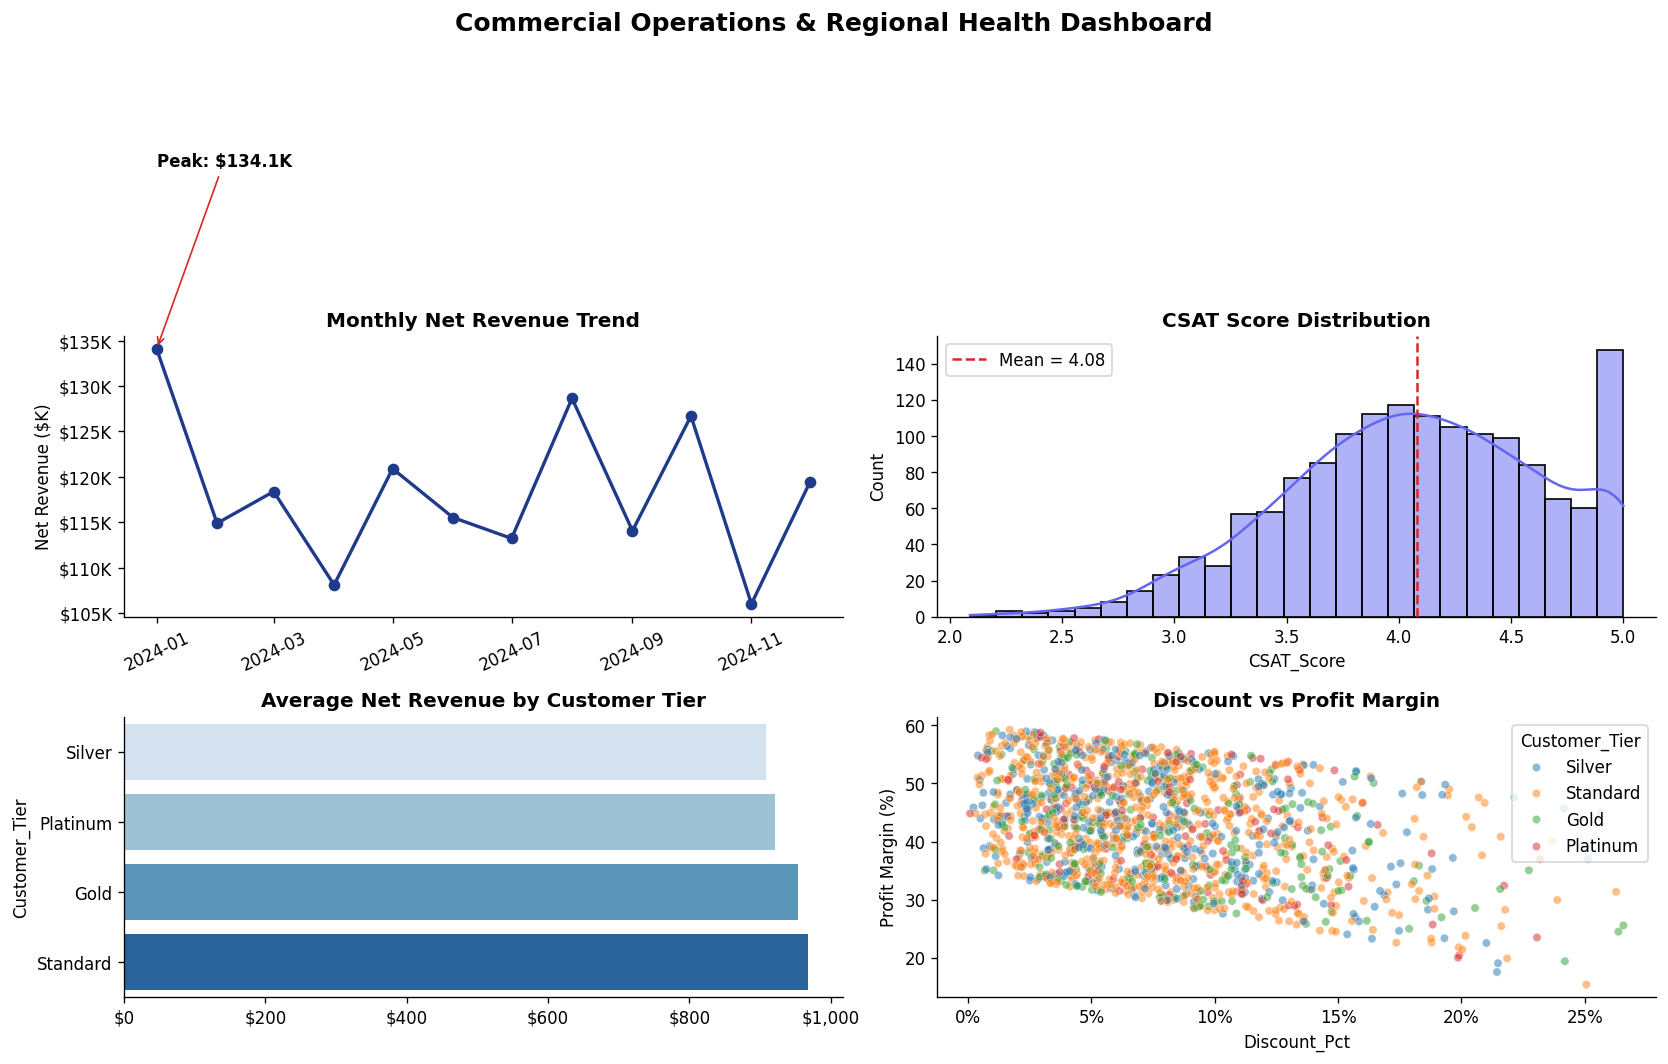

In [24]:
# ==============================================================================
# SECTION 6: STUDENT LAB ASSIGNMENT (PORTFOLIO DELIVERABLE)
# ==============================================================================
"""
🎓 STUDENT LAB INSTRUCTIONS:
Using the loaded `df` dataset (or your Day 3 dataset), build your own 4-panel visual dashboard
addressing 4 distinct analytical dimensions.

DASHBOARD MANDATORY SPECIFICATIONS:
1. Grid Layout: Must use `plt.subplots(2, 2, figsize=(14, 9))` in the Object-Oriented style.
2. Panel 1 (Trend): A temporal line plot showing cumulative or monthly volume/revenue.
3. Panel 2 (Distribution): A histogram or KDE plot showing the distribution of CSAT or Margin.
4. Panel 3 (Comparison): A horizontal or vertical bar chart comparing performance across Regions or Tiers.
5. Panel 4 (Relationship): A scatter or regression plot (e.g. Unit Price vs Units Sold or Discount vs Profit).
6. Professional Polishing: Custom titles, formatted tick labels ($, %, or K), descriptive legends, and at least ONE annotation.
"""

# ------------------------------------------------------------------------------
# STUDENT WORKSPACE (WRITE YOUR SOLUTION BELOW)
# ------------------------------------------------------------------------------
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.ticker as mticker, seaborn as sns


# 1. Initialize Figure and 2x2 Subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Commercial Operations & Regional Health Dashboard", fontsize=15, fontweight="bold")

# TODO 1: Complete Panel [0, 0] - Trend Analysis
# axes[0, 0].plot(...)
monthly = df.groupby("Month")["Net_Revenue"].sum()
axes[0, 0].plot(monthly.index, monthly.values / 1e3, marker="o", color="#1e3a8a", lw=2)
axes[0, 0].set_title("Monthly Net Revenue Trend", fontweight="bold")
axes[0, 0].set_ylabel("Net Revenue ($K)")
axes[0, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter("$%.0fK"))
axes[0, 0].tick_params(axis='x', rotation=25)
peak_month = monthly.idxmax()
axes[0, 0].annotate(f"Peak: ${monthly.max()/1e3:.1f}K",
                     xy=(peak_month, monthly.max() / 1e3),
                     xytext=(peak_month, monthly.max() / 1e3 * 1.15),
                     arrowprops=dict(arrowstyle="->", color="#dc2626"),
                     fontweight="bold")
# TODO 2: Complete Panel [0, 1] - Distribution Analysis
# sns.histplot(..., ax=axes[0, 1])
sns.histplot(df["CSAT_Score"], bins=25, kde=True, ax=axes[0, 1], color="#6366f1")
axes[0, 1].axvline(df["CSAT_Score"].mean(), color="#dc2626", linestyle="--",
                    label=f"Mean = {df['CSAT_Score'].mean():.2f}")
axes[0, 1].set_title("CSAT Score Distribution", fontweight="bold")
axes[0, 1].legend()
# TODO 3: Complete Panel [1, 0] - Categorical Comparison
# sns.barplot(..., ax=axes[1, 0])
tier_rev = df.groupby("Customer_Tier")["Net_Revenue"].mean().sort_values()
sns.barplot(x=tier_rev.values, y=tier_rev.index, ax=axes[1, 0],
            hue=tier_rev.index, palette="Blues", legend=False)
axes[1, 0].set_title("Average Net Revenue by Customer Tier", fontweight="bold")
axes[1, 0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
# TODO 4: Complete Panel [1, 1] - Bivariate Relationship
# sns.scatterplot(..., ax=axes[1, 1])
sns.scatterplot(data=df, x="Discount_Pct", y="Profit_Margin_Pct",
                 hue="Customer_Tier", alpha=0.5, ax=axes[1, 1], s=25)
axes[1, 1].set_title("Discount vs Profit Margin", fontweight="bold")
axes[1, 1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
axes[1, 1].set_ylabel("Profit Margin (%)")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("student_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()